In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

In [7]:
def derive_6th_v2(x, dy):
    rhs = np.zeros_like(x)
    ab = np.zeros((3, x.shape[0]))
    a = -1 / 36
    b = -7 / 9
    c = 1 / 3
    
    rhs[2:-2] = a * (x[0:-4] - x[4:]) + b * (x[1:-3] - x[3:-1])
    rhs[0] = (-5 / 2) * x[0] + 2 * x[1] + (1 / 2) * x[2]
    rhs[1] = (3 / 4) * (x[2] - x[0])
    rhs[-2] = -(3 / 4) * (x[-3] - x[-1])
    rhs[-1] = -(-5 / 2) * x[-1] - 2 * x[-2] - (1 / 2) * x[-3]
    rhs[:] = rhs[:] / dy
    
    ab[0, 2:] = c
    ab[1, :] = 1
    ab[2, :-2] = c
    ab[0, 1] = 2
    ab[0, 2] = 1 / 4
    ab[0, -1] = 1 / 4
    ab[2, -2] = 2
    ab[2, 0] = 1 / 4
    ab[2, -3] = 1 / 4
    x_prime = solve_banded((1, 1), ab, rhs)
    return x_prime

In [47]:
def derive_4th(field, dy, direction=0):
    field_reordered = np.moveaxis(field, direction, 0)
    shape_reordered = field_reordered.shape
    rhs = np.zeros_like(field_reordered)
    rhs[1:-1] = field_reordered[2:] - field_reordered[0:-2]
    rhs[0, ...] = 0
    rhs[-1, ...] = 0
    rhs *= 3.0 / dy
    length = field.shape[direction]
    ab = np.zeros((3, length))
    ab[0, 2:] = 1
    ab[1, :] = 4
    ab[2, :-2] = 1
    # BC
    ab[0, 1] = 0
    ab[2, -2] = 0
    rhs_reshaped = rhs.reshape(length, -1)
    field_prime_reshaped = solve_banded((1, 1), ab, rhs_reshaped)
    field_prime_reshaped = field_prime_reshaped.reshape(shape_reordered)
    field_prime = np.moveaxis(field_prime_reshaped, 0, direction)
    return field_prime

In [56]:
def rmse(X, Y):
    return np.sqrt(np.mean((X - Y) ** 2))

def rel_rmse(X, Y):
    return rmse(X, Y) / rmse(Y, 0)

def get_rel_rmse(deriv_operator, resolution):
    d = 2 * np.pi
    h = d / (resolution - 1)
    x = np.linspace(0, d, resolution, endpoint=True)
    f = np.sin(2*x) + 0.3*np.cos(3*x) + 0.15*np.sin(5*x + 0.7)
    df_ana = 2*np.cos(2*x) - 0.9*np.sin(3*x) + 0.75*np.cos(5*x + 0.7)
    return rel_rmse(deriv_operator(f, h), df_ana)

def add_plot_line(deriv_operator, label):
    resolutions = [2 ** i * 10 for i in range(1, 12)]
    errors = [get_rel_rmse(deriv_operator, r) for r in resolutions]
    plt.plot(resolutions, errors, label=label)
 

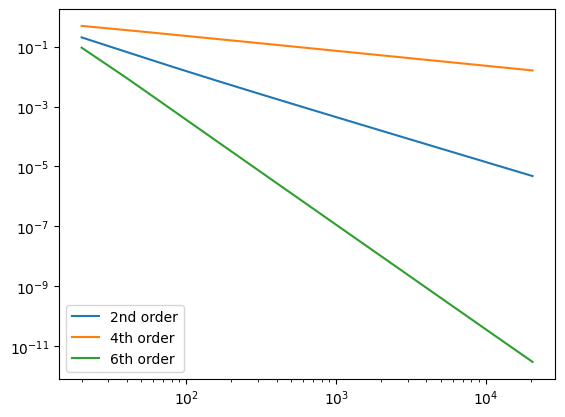

In [57]:
add_plot_line(np.gradient, "2nd order")
add_plot_line(derive_4th, "4th order")
add_plot_line(derive_6th_v2, "6th order")
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()

4th order function has wrong BC